Copyright (c) Microsoft Corporation. All rights reserved.

Licensed under the MIT License.

# TEMPO Building Volume Dataset Tutorial

## Introduction

Urban areas are expanding and densifying rapidly across the globe, yet tracking the pace and patterns of this growth at fine temporal resolution remains challenging. **TEMPO** is a global, temporally resolved dataset of building volume-encompassing both density and height—derived from high-resolution satellite imagery using a deep learning approach. By pairing building footprint and height data from existing datasets with quarterly PlanetScope basemap satellite images, we train a model that produces consistent, quarterly building maps.

**We are open sourcing this dataset for five diverse urban regions** to enable researchers, urban planners, and policymakers to understand and analyze urban development patterns across different contexts and continents. The data is available through Cloud Optimized GeoTIFF (COG) tiles that can be accessed directly over HTTPS.

The five locations included in this release are:
- **Bamako, Mali** – West African capital experiencing rapid urbanization
- **Guangdong Province, China** – Major economic region with dense urban development
- **Guatemala Department, Guatemala** – Central American urban area
- **Lusaka District, Zambia** – Growing East African urban center
- **Nakuru, Kenya** – Medium-sized city with dynamic expansion patterns

This tutorial demonstrates how to explore and analyze the TEMPO dataset by mainly focusing on two contrasting locations: **Nakuru, Kenya** and **Guangdong Province, China**.

By analyzing these contrasting cases, this tutorial illustrates how TEMPO can capture urban growth dynamics at different scales and development patterns. You will learn to:
- Load the dataset's Cloud Optimized GeoTIFF (COG) tiles directly over HTTPS
- Interpret the two data bands (density + height) and derive building volume proxies
- Summarize temporal trends, growth rates, and stability metrics
- Compare multiple locations to understand diverse urban growth patterns
- Visualize spatial distributions, change maps, and temporal evolution

---

## Table of Contents

1. [Setup & Imports](#1.-Setup-&-Imports)
2. [Load & Preview a Single Tile](#2.-Load-&-Preview-a-Single-Tile)
3. [Temporal Summary for One Location](#3.-Temporal-Summary-for-One-Location)
4. [Growth Rates & Stability (Year-over-Year)](#4.-Growth-Rates-&-Stability-(Year-over-Year))
5. [Cross-Location Comparative Analysis](#5.-Cross-Location-Comparative-Analysis)
6. [Distributional Views](#6.-Distributional-Views)
7. [Spatial Change Highlighting](#7.-Spatial-Change-Highlighting)
8. [Optional: Simple Animation (Density Evolution)](#8.-Optional:-Simple-Animation-(Density-Evolution))
9. [Insights & Takeaways](#9.-Insights-&-Takeaways)

## 1. Setup & Imports

In this section, we'll import the necessary libraries and define helper functions for loading and processing the TEMPO dataset. We'll also configure visualization settings and define the locations and time periods we'll analyze throughout the tutorial.

In [2]:
import concurrent.futures
import functools
import os
import warnings

import imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from PIL import Image, ImageDraw, ImageFont

warnings.filterwarnings("ignore")

In [3]:
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (10, 6)

LOCATIONS = [
    "bamako",
    "guangdong_province",
    "guatemala_department",
    "lusaka_district",
    "nakuru",
]
QUARTERS = [
    f"{year}q{q}"
    for year in range(2020, 2026)
    for q in range(1, 5)
    if not (year == 2025 and q > 2)
][1:]  # from 2020q2 up to 2025q2
BASE_URL = (
    "https://opendata.aiforgood.ai/building-density/locations/{location}/{yq}_cog.tif"
)


@functools.lru_cache(maxsize=64)
def load_tile(location: str, yq: str):
    """Load density and height data for a specific location and quarter.

    Args:
        location: Location identifier (e.g., 'nakuru', 'guangdong_province')
        yq: Year-quarter string (e.g., '2020q2')

    Returns:
        tuple: (density, height_m, profile) where:
            - density: 2D numpy array of building density values (0-1)
            - height_m: 2D numpy array of building heights in meters
            - profile: rasterio profile dictionary with metadata
    """
    url = BASE_URL.format(location=location, yq=yq)
    try:
        with rasterio.open(url) as src:
            arr = src.read(masked=True).astype(
                np.float32
            )  # shape (2, H, W), auto-mask nodata
            density = arr[0]
            height_m = arr[1] * 100.0  # rescale
            profile = src.profile.copy()

            profile.update({"dtype": "float32", "count": 2})
            return density, height_m, profile
    except Exception as e:
        raise RuntimeError(f"Failed to load tile for {location} {yq}: {e}")

def pixel_area_m2(profile):
    """Calculate the area of a single pixel in square meters.

    Args:
        profile: rasterio profile dictionary containing transform information

    Returns:
        float: Pixel area in square meters
    """
    transform = profile["transform"]
    pw = abs(transform.a)
    ph = abs(transform.e)
    return pw * ph


def summarize_location(location: str, max_workers: int = None):
    """Summarize building metrics for a location across all quarters using parallel processing.

    Args:
        location: Location identifier (e.g., 'nakuru', 'guangdong_province')
        max_workers: Maximum number of worker threads (defaults to min(8, cpu_count))

    Returns:
        pd.DataFrame: DataFrame with quarterly metrics including mean density, mean height,
                      total volume proxy, and built fraction
    """

    max_workers = min(8, (os.cpu_count() or 4))

    def _process_q(yq: str):
        try:
            density, height_m, profile = load_tile(location, yq)
            pix_area = pixel_area_m2(profile)
            mean_density = float(np.nanmean(density))
            mask = density > 0
            mean_height = float(np.nanmean(height_m[mask])) if np.any(mask) else 0.0
            volume_proxy = density * height_m
            total_volume_proxy = float(np.nansum(volume_proxy) * pix_area)
            built_pixels = int(np.sum(mask))
            total_pixels = int(density.size)
            year = int(yq[:4])
            quarter = int(yq[-1])
            return {
                "location": location,
                "year_quarter": yq,
                "year": year,
                "quarter": quarter,
                "mean_density": mean_density,
                "mean_height_m": mean_height,
                "total_volume_proxy_m3": total_volume_proxy,
                "built_fraction": built_pixels / total_pixels if total_pixels else 0.0,
                "built_pixels": built_pixels,
                "total_pixels": total_pixels,
            }
        except Exception:
            year = int(yq[:4])
            quarter = int(yq[-1])
            return {
                "location": location,
                "year_quarter": yq,
                "year": year,
                "quarter": quarter,
                "mean_density": np.nan,
                "mean_height_m": np.nan,
                "total_volume_proxy_m3": np.nan,
                "built_fraction": np.nan,
                "built_pixels": 0,
                "total_pixels": 0,
            }

    records = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(_process_q, yq): yq for yq in QUARTERS}
        for fut in concurrent.futures.as_completed(futures):
            records.append(fut.result())

    # preserve QUARTERS order
    q_index = {q: i for i, q in enumerate(QUARTERS)}
    records.sort(key=lambda r: q_index.get(r["year_quarter"], 0))
    return pd.DataFrame.from_records(records)


def yoy_growth(df, value_col):
    """Calculate year-over-year growth rates for a given metric.

    Compares the same quarter across consecutive years to compute growth percentages.

    Args:
        df: DataFrame with 'year', 'quarter', and value columns
        value_col: Name of the column to calculate growth for

    Returns:
        pd.DataFrame: DataFrame with from_year, to_year, quarter, and growth_pct columns
    """
    # Year-over-year growth between same quarter consecutive years
    rows = []
    for q in sorted(df["quarter"].unique()):
        this_q = df[df["quarter"] == q].set_index("year").sort_index()
        for y in this_q.index[:-1]:
            if (y + 1) in this_q.index:
                prev = this_q.loc[y, value_col]
                nxt = this_q.loc[y + 1, value_col]
                if prev != 0:
                    rows.append(
                        {
                            "quarter": q,
                            "from_year": y,
                            "to_year": y + 1,
                            "growth_pct": (nxt - prev) / prev * 100,
                        }
                    )
    return pd.DataFrame(rows)


print("Environment ready. Locations:", LOCATIONS)

Environment ready. Locations: ['bamako', 'guangdong_province', 'guatemala_department', 'lusaka_district', 'nakuru']


## 2. Load & Preview a Single Tile

Let's load and visualize a single quarter of data to understand the structure and range of the density and height values. This will help us interpret the patterns we see in later sections.
We'll inspect density and height for one quarter to understand dynamic range and spatial layout.

Shape: (1024, 1024) Pixel area (m^2): 1460.6548232672033


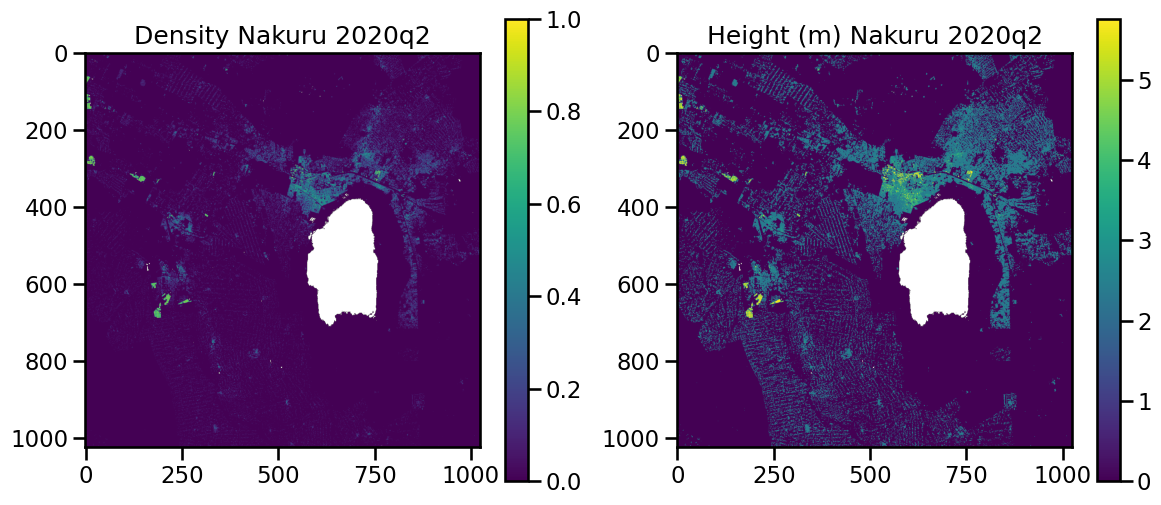

,stat,value
0,mean_density,0.019742
1,mean_height_m_nonzero,2.487686
2,p95_height_m,2.400000


In [4]:
example_loc = "nakuru"
example_yq = QUARTERS[0]
density, height_m, profile = load_tile(example_loc, example_yq)
print("Shape:", density.shape, "Pixel area (m^2):", pixel_area_m2(profile))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(density, cmap="viridis", vmin=0, vmax=1)
axes[0].set_title(f"Density {example_loc.capitalize()} {example_yq}")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(
    height_m, cmap="viridis", vmin=0, vmax=np.nanpercentile(height_m, 99.9)
)
axes[1].set_title(f"Height (m) {example_loc.capitalize()} {example_yq}")
plt.colorbar(im1, ax=axes[1])
plt.show()
pd.DataFrame(
    {
        "stat": ["mean_density", "mean_height_m_nonzero", "p95_height_m"],
        "value": [
            float(np.nanmean(density)),
            float(np.nanmean(height_m[density > 0])),
            float(np.nanpercentile(height_m, 95)),
        ],
    }
)

## 3. Temporal Summary for One Location

Now we'll compute quarterly summary statistics across all available time periods for a single location. By aggregating metrics like mean density, mean height, and total volume proxy, we can identify overall trends in urban development over time.
Compute quarterly metrics for density, average height over built pixels, and total volume proxy.

In [5]:
nakuru_df = summarize_location("nakuru")
nakuru_df.head()

,location,year_quarter,year,quarter,mean_density,mean_height_m,total_volume_proxy_m3,built_fraction,built_pixels,total_pixels
0,nakuru,2020q2,2020,2,0.019742,2.487686,8.341445e+07,0.172903,181302,1048576
1,nakuru,2020q3,2020,3,0.019786,2.490744,8.399529e+07,0.173298,181716,1048576
2,nakuru,2020q4,2020,4,0.019827,2.487952,8.380223e+07,0.174176,182637,1048576
3,nakuru,2021q1,2021,1,0.019975,2.482798,8.376186e+07,0.175967,184515,1048576
4,nakuru,2021q2,2021,2,0.020200,2.482769,8.472582e+07,0.177356,185971,1048576


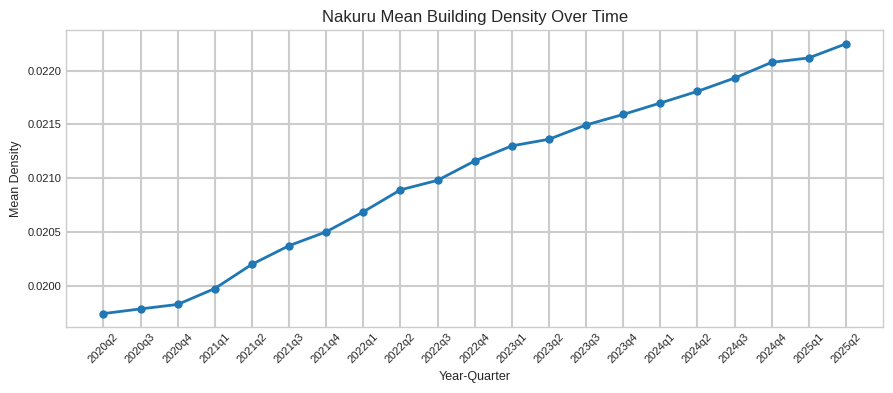

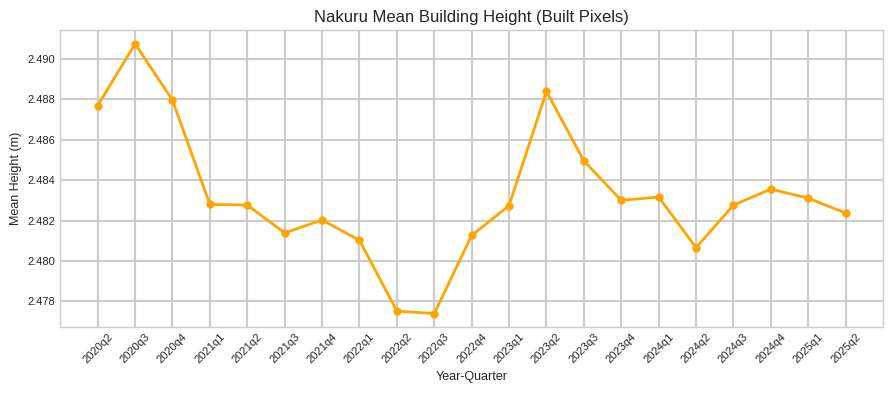

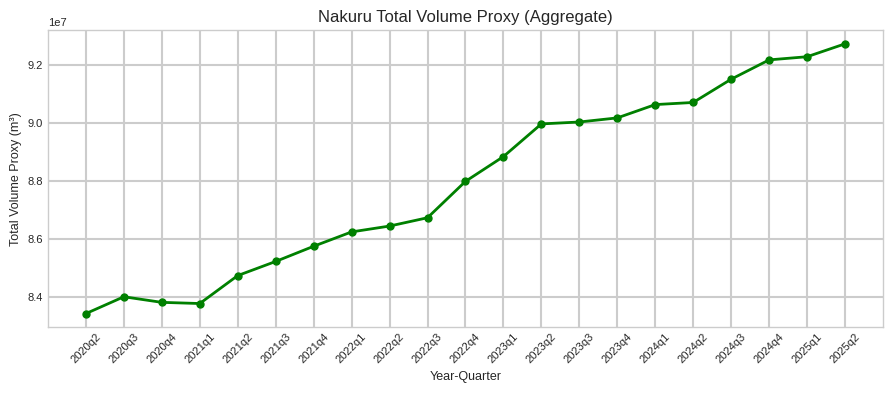

In [6]:
# Set visualization parameters
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 12,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
    }
)

# 1. Mean Building Density Over Time
plt.figure(figsize=(9, 4))
plt.plot(
    nakuru_df["year_quarter"],
    nakuru_df["mean_density"],
    marker="o",
    linewidth=2,
    markersize=5,
)
plt.title("Nakuru Mean Building Density Over Time")
plt.xlabel("Year-Quarter")
plt.ylabel("Mean Density")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Mean Building Height (Built Pixels)
plt.figure(figsize=(9, 4))
plt.plot(
    nakuru_df["year_quarter"],
    nakuru_df["mean_height_m"],
    color="orange",
    marker="o",
    linewidth=2,
    markersize=5,
)
plt.title("Nakuru Mean Building Height (Built Pixels)")
plt.xlabel("Year-Quarter")
plt.ylabel("Mean Height (m)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Total Volume Proxy (Aggregate)
plt.figure(figsize=(9, 4))
plt.plot(
    nakuru_df["year_quarter"],
    nakuru_df["total_volume_proxy_m3"],
    color="green",
    marker="o",
    linewidth=2,
    markersize=5,
)
plt.title("Nakuru Total Volume Proxy (Aggregate)")
plt.xlabel("Year-Quarter")
plt.ylabel("Total Volume Proxy (m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Same analysis for Guangdong Province
guangdong_province_df = summarize_location("guangdong_province")
guangdong_province_df.head()

,location,year_quarter,year,quarter,mean_density,mean_height_m,total_volume_proxy_m3,built_fraction,built_pixels,total_pixels
0,guangdong_province,2020q2,2020,2,0.027184,3.394844,3.239887e+10,0.060260,24879812,412876800
1,guangdong_province,2020q3,2020,3,0.027056,3.397351,3.230947e+10,0.060210,24859397,412876800
2,guangdong_province,2020q4,2020,4,0.027541,3.415094,3.296683e+10,0.060903,25145375,412876800
3,guangdong_province,2021q1,2021,1,0.027986,3.443009,3.380761e+10,0.061492,25388818,412876800
4,guangdong_province,2021q2,2021,2,0.028341,3.452748,3.432334e+10,0.061833,25529224,412876800


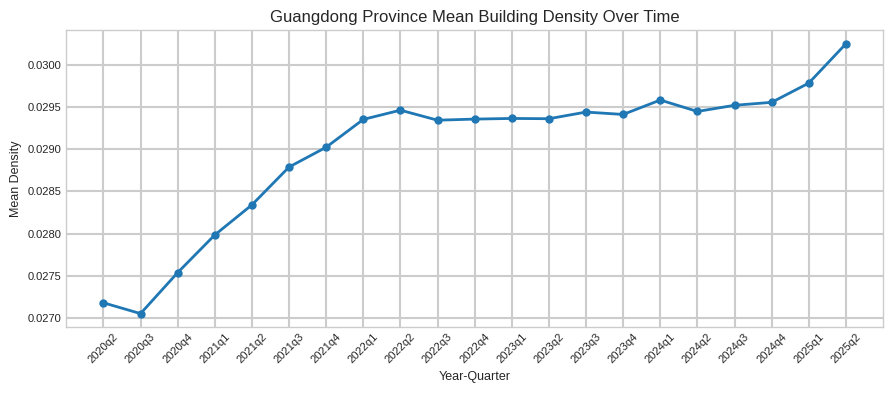

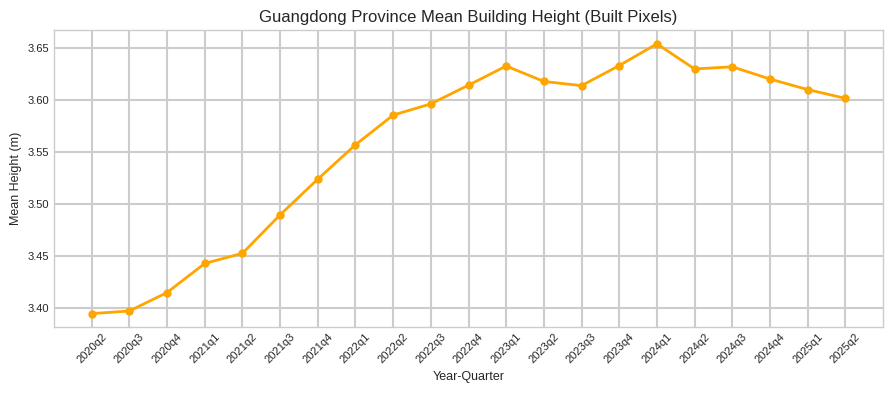

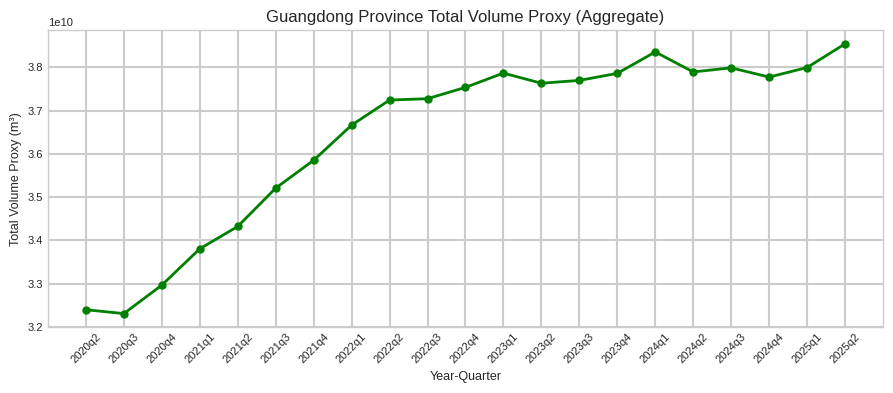

In [8]:
# Note: this cell may take 1-2 minutes to execute

# 1. Mean Building Density Over Time
plt.figure(figsize=(9, 4))
plt.plot(
    guangdong_province_df["year_quarter"],
    guangdong_province_df["mean_density"],
    marker="o",
    linewidth=2,
    markersize=5,
)
plt.title("Guangdong Province Mean Building Density Over Time")
plt.xlabel("Year-Quarter")
plt.ylabel("Mean Density")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Mean Building Height (Built Pixels)
plt.figure(figsize=(9, 4))
plt.plot(
    guangdong_province_df["year_quarter"],
    guangdong_province_df["mean_height_m"],
    color="orange",
    marker="o",
    linewidth=2,
    markersize=5,
)
plt.title("Guangdong Province Mean Building Height (Built Pixels)")
plt.xlabel("Year-Quarter")
plt.ylabel("Mean Height (m)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Total Volume Proxy (Aggregate)
plt.figure(figsize=(9, 4))
plt.plot(
    guangdong_province_df["year_quarter"],
    guangdong_province_df["total_volume_proxy_m3"],
    color="green",
    marker="o",
    linewidth=2,
    markersize=5,
)
plt.title("Guangdong Province Total Volume Proxy (Aggregate)")
plt.xlabel("Year-Quarter")
plt.ylabel("Total Volume Proxy (m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpreting Trends

* For both places, the rising mean density suggests infill or expansion of built coverage.
* In Nakuru, the mean building height has remained relatively stable, indicating that most urban growth is driven by horizontal expansion and infill rather than vertical construction.
* In Guangdong, the mean height has been rising, suggesting that development involves not only expanding into new areas but also constructing taller buildings.

The volume proxy, which combines both height and density, reinforces this pattern:

* For Nakuru, growth is primarily due to the horizontal spread of built-up areas.
* For Guangdong, growth reflects a combination of new development and increasing building heights, signaling both outward and upward expansion.

## 4. Growth Rates & Stability (Year-over-Year)

To better understand the pace of urban development, we'll calculate year-over-year growth rates by comparing the same quarter across consecutive years. This helps us identify periods of rapid expansion or stabilization.

In [9]:
nakuru_growth_density = yoy_growth(nakuru_df, "mean_density")
nakuru_growth_height = yoy_growth(nakuru_df, "mean_height_m")
nakuru_growth_volume = yoy_growth(nakuru_df, "total_volume_proxy_m3")
nakuru_growth_density.head(), nakuru_growth_height.head(), nakuru_growth_volume.head()

(   quarter  from_year  to_year  growth_pct
 0        1       2021     2022    3.566903
 1        1       2022     2023    2.964396
 2        1       2023     2024    1.869169
 3        1       2024     2025    1.932079
 4        2       2020     2021    2.319193,
    quarter  from_year  to_year  growth_pct
 0        1       2021     2022   -0.071311
 1        1       2022     2023    0.069034
 2        1       2023     2024    0.017127
 3        1       2024     2025   -0.002241
 4        2       2020     2021   -0.197627,
    quarter  from_year  to_year  growth_pct
 0        1       2021     2022    2.949447
 1        1       2022     2023    3.013346
 2        1       2023     2024    2.019649
 3        1       2024     2025    1.822074
 4        2       2020     2021    1.572115)

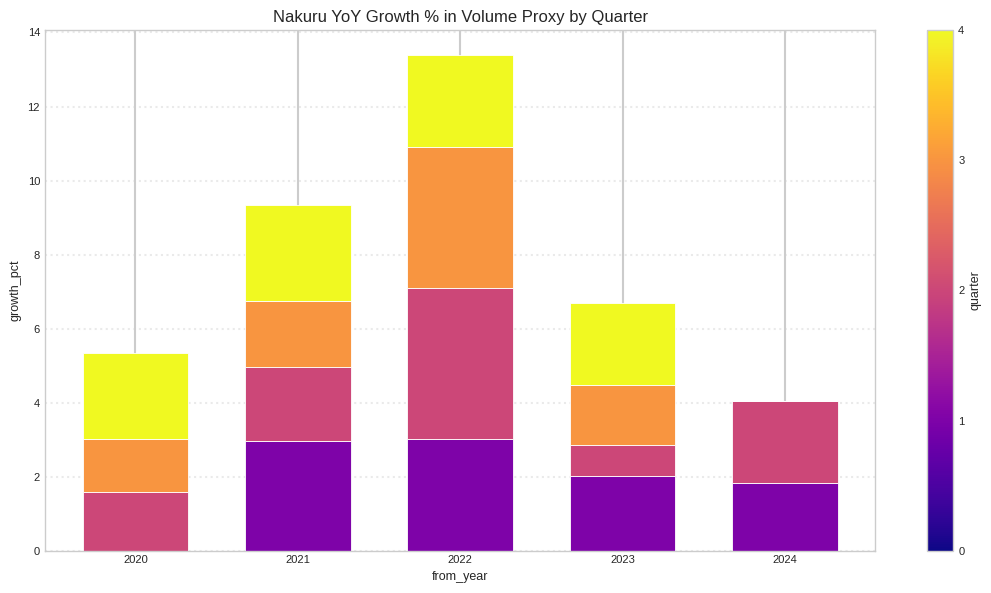

In [11]:
# Prepare stacked bar chart for Nakuru
df = nakuru_growth_volume.copy()
quarters = sorted(df["quarter"].unique())
pivot = (
    df.pivot_table(
        index="from_year", columns="quarter", values="growth_pct", aggfunc="sum"
    )
    .reindex(columns=quarters)
    .fillna(0.0)
)
years = pivot.index.values

# Plot
plt.figure(figsize=(11, 6))
x = np.arange(len(years))
width = 0.65
cmap = plt.cm.plasma
norm = Normalize(vmin=0, vmax=4)
colors = [cmap(norm(q)) for q in quarters]

bottom = np.zeros(len(x))
for q, color in zip(quarters, colors):
    vals = pivot[q].values
    plt.bar(
        x,
        vals,
        width=width,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=0.6,
    )
    bottom += vals

plt.title("Nakuru YoY Growth % in Volume Proxy by Quarter")
plt.xlabel("from_year")
plt.ylabel("growth_pct")
plt.xticks(x, years, rotation=0)
plt.grid(axis="y", linestyle=":", alpha=0.4)

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("quarter")
cbar.set_ticks([0, 1, 2, 3, 4])

plt.tight_layout()
plt.show()

In [13]:
guangdong_province_growth_density = yoy_growth(guangdong_province_df, "mean_density")
guangdong_province_growth_height = yoy_growth(guangdong_province_df, "mean_height_m")
guangdong_province_growth_volume = yoy_growth(
    guangdong_province_df, "total_volume_proxy_m3"
)
(
    guangdong_province_growth_density.head(),
    guangdong_province_growth_height.head(),
    guangdong_province_growth_volume.head(),
)

(   quarter  from_year  to_year  growth_pct
 0        1       2021     2022    4.880033
 1        1       2022     2023    0.038570
 2        1       2023     2024    0.741190
 3        1       2024     2025    0.676295
 4        2       2020     2021    4.256633,
    quarter  from_year  to_year  growth_pct
 0        1       2021     2022    3.310236
 1        1       2022     2023    2.125546
 2        1       2023     2024    0.587094
 3        1       2024     2025   -1.202360
 4        2       2020     2021    1.705652,
    quarter  from_year  to_year  growth_pct
 0        1       2021     2022    8.453736
 1        1       2022     2023    3.281128
 2        1       2023     2024    1.291800
 3        1       2024     2025   -0.940357
 4        2       2020     2021    5.939942)

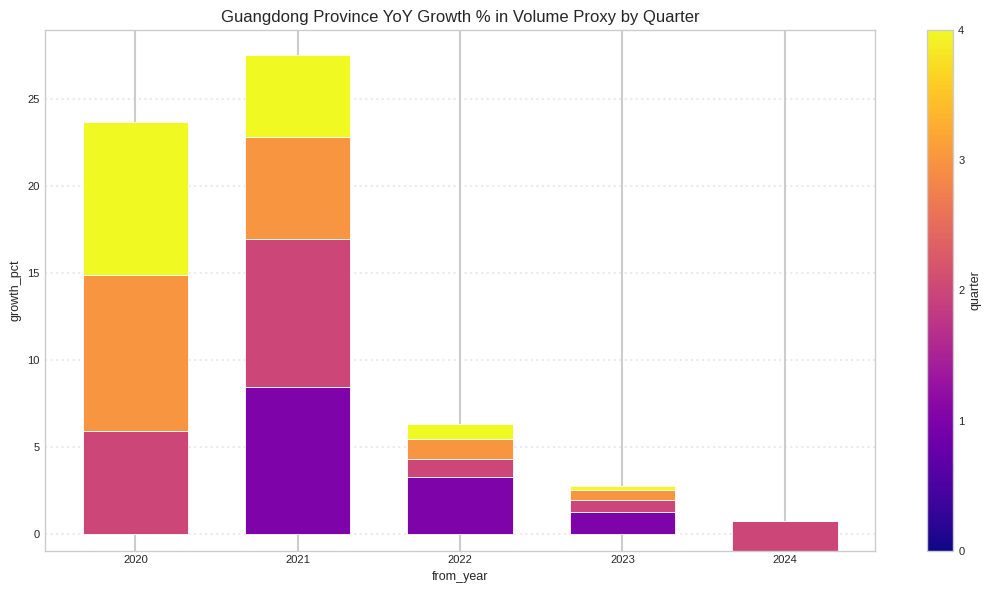

In [14]:
# Prepare stacked bar chart for Guangdong Province
df = guangdong_province_growth_volume.copy()

quarters = sorted(df["quarter"].unique())
pivot = (
    df.pivot_table(
        index="from_year", columns="quarter", values="growth_pct", aggfunc="sum"
    )
    .reindex(columns=quarters)
    .fillna(0.0)
)
years = pivot.index.values

# Plot
plt.figure(figsize=(11, 6))
x = np.arange(len(years))
width = 0.65
cmap = plt.cm.plasma
norm = Normalize(vmin=0, vmax=4)
colors = [cmap(norm(q)) for q in quarters]

bottom = np.zeros(len(x))
for q, color in zip(quarters, colors):
    vals = pivot[q].values
    plt.bar(
        x,
        vals,
        width=width,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=0.6,
    )
    bottom += vals

plt.title("Guangdong Province YoY Growth % in Volume Proxy by Quarter")
plt.xlabel("from_year")
plt.ylabel("growth_pct")
plt.xticks(x, years, rotation=0)
plt.grid(axis="y", linestyle=":", alpha=0.4)

# Add colorbar with fixed 0–4 scale
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("quarter")
cbar.set_ticks([0, 1, 2, 3, 4])

plt.tight_layout()
plt.show()

## 5. Cross-Location Comparative Analysis

In this section, we'll analyze all five locations together to compare their urban development characteristics. By visualizing metrics across different locations, we can identify common patterns and unique trajectories in building density, height, and volume growth.
Aggregate metrics for all locations; compare structure and growth intensity.

In [15]:
# Note: this cell may take a few minutes to execute

all_dfs = []
max_workers = min(8, len(LOCATIONS))
with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = {ex.submit(summarize_location, loc): loc for loc in LOCATIONS}
    for fut in concurrent.futures.as_completed(futures):
        res = fut.result()
        if res is not None:
            all_dfs.append(res)

all_df = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
summary_latest = (
    all_df.sort_values("year_quarter")
    .groupby("location")
    .tail(1)
    .sort_values("total_volume_proxy_m3", ascending=False)
)
summary_latest[
    [
        "location",
        "year_quarter",
        "mean_density",
        "mean_height_m",
        "built_fraction",
        "total_volume_proxy_m3",
    ]
]

,location,year_quarter,mean_density,mean_height_m,built_fraction,total_volume_proxy_m3
104,guangdong_province,2025q2,0.030245,3.601563,0.064986,3.854560e+10
83,guatemala_department,2025q2,0.031062,2.773854,0.112825,5.739032e+08
62,bamako,2025q2,0.089929,2.588513,0.375109,2.824585e+08
41,lusaka_district,2025q2,0.050715,2.547938,0.240864,2.809268e+08
20,nakuru,2025q2,0.022249,2.482372,0.191122,9.272114e+07


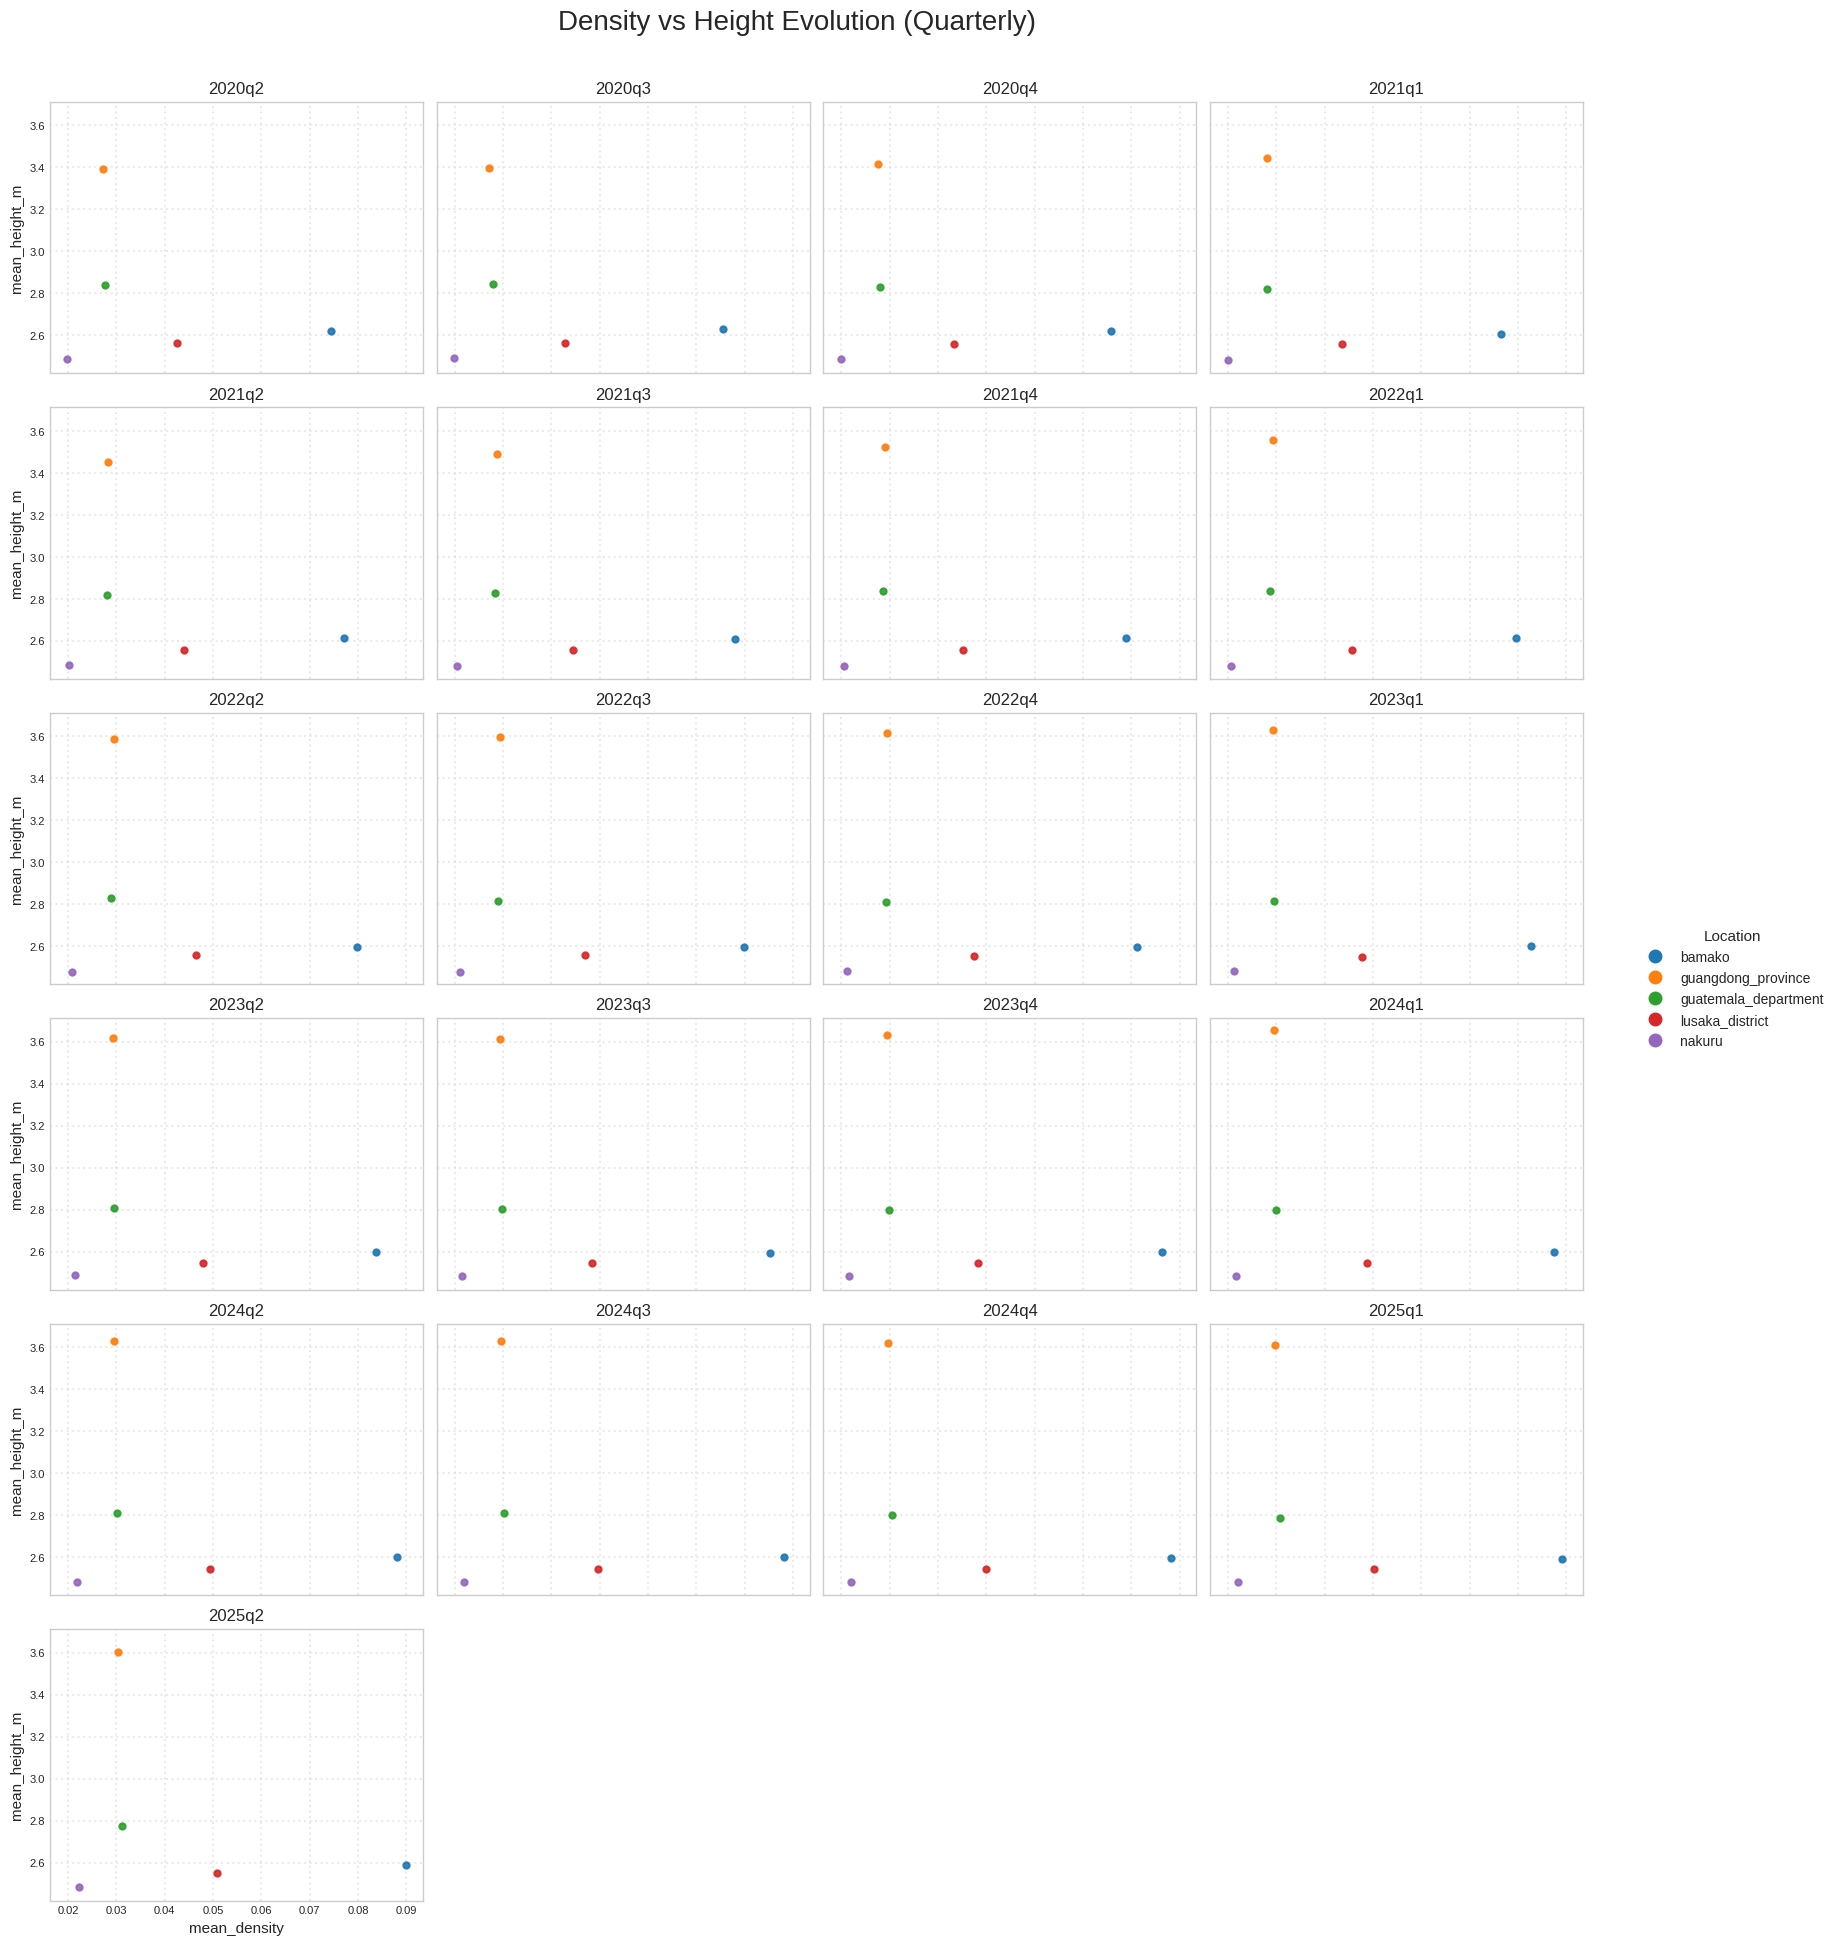

In [16]:
# Scatter plot: Density vs Height by quarter
quarters = sorted(all_df["year_quarter"].unique())
locations = sorted(all_df["location"].unique())

# Color per location (consistent across panels)
palette = plt.cm.tab10.colors
loc_color = {loc: palette[i % len(palette)] for i, loc in enumerate(locations)}

n = len(quarters)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(4.0 * ncols, 3.2 * nrows), sharex=True, sharey=True
)
axes = np.ravel(axes)

for i, q in enumerate(quarters):
    ax = axes[i]
    sub = all_df[all_df["year_quarter"] == q]
    for loc in locations:
        d = sub[sub["location"] == loc]
        ax.scatter(
            d["mean_density"],
            d["mean_height_m"],
            s=20,
            color=loc_color[loc],
            label=loc,
            alpha=0.9,
        )
    ax.set_title(str(q))
    ax.grid(True, linestyle=":", alpha=0.4)

# Axis labels on outer edges only
for idx, ax in enumerate(axes):
    if idx // ncols == nrows - 1:
        ax.set_xlabel("mean_density", fontsize=11)
    if idx % ncols == 0:
        ax.set_ylabel("mean_height_m", fontsize=11)

for ax in axes:
    ax.set_title(ax.get_title(), fontsize=12, pad=6)

# Remove any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# One legend for all panels
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=loc_color[loc], label=loc)
    for loc in locations
]
fig.legend(
    handles=handles,
    labels=locations,
    title="Location",
    title_fontsize=11,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)
fig.suptitle("Density vs Height Evolution (Quarterly)", fontsize=20, y=1.01)
fig.tight_layout()
plt.show()

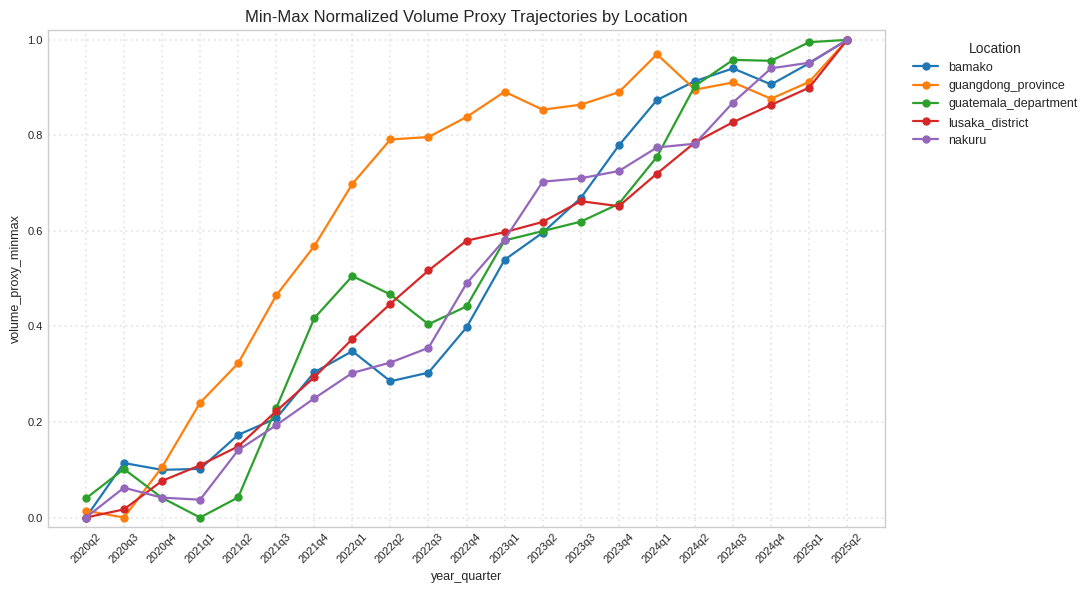

In [17]:
# Min–max per location
g = all_df.groupby("location")["total_volume_proxy_m3"]
mn = g.transform("min")
mx = g.transform("max")
den = mx - mn
all_df["vol_minmax"] = np.where(
    den > 0, (all_df["total_volume_proxy_m3"] - mn) / den, 0.0
)

# Y-axis padding (2%)
vmin, vmax = all_df["vol_minmax"].min(), all_df["vol_minmax"].max()
pad = max((vmax - vmin) * 0.02, 1e-3)
ymin, ymax = vmin - pad, vmax + pad

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
locations = sorted(all_df["location"].unique())

for loc in locations:
    d = all_df[all_df["location"] == loc].sort_values("year_quarter")
    ax.plot(
        d["year_quarter"],
        d["vol_minmax"],
        label=loc,
        marker="o",
        linewidth=1.6,
        markersize=5,
    )

ax.set_ylim(ymin, ymax)
ax.set_title("Min-Max Normalized Volume Proxy Trajectories by Location")
ax.set_xlabel("year_quarter")
ax.set_ylabel("volume_proxy_minmax")
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend(
    title="Location",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Structural Insights
- Points shifting up: vertical growth emphasis.
- Points shifting right: horizontal spread (density coverage).
- Diagonal movement: combined intensification.
- Divergence across locations indicates differing development models (higher buildings vs newly built areas).

## 6. Distributional Views

Summary statistics like means can mask important heterogeneity within a location. Here we'll examine the full distributions of density and height values to understand the diversity of building types and detect shifts in development patterns between different time periods.
Understand heterogeneity inside a tile: density and height distributions for one quarter vs another quarter.

In [18]:
def plot_distributions(location, yq_list):
    """Plot density and height distributions for multiple quarters.

    Creates histograms showing the distribution of density (log-scale) and height values
    for built pixels, helping identify shifts in building characteristics over time.

    Args:
        location: Location identifier (e.g., 'nakuru', 'guangdong_province')
        yq_list: List of year-quarter strings to visualize (e.g., ['2020q2', '2025q2'])
    """
    fig, axes = plt.subplots(len(yq_list), 2, figsize=(14, 5 * len(yq_list)))
    # ensure axes is 2D (handles single-row case)
    if axes.ndim == 1:
        axes = axes.reshape(1, -1)
    for i, yq in enumerate(yq_list):
        density, height_m, _ = load_tile(location, yq)

        # Density: log-scale histogram for positive values, report zeros
        arr = density.flatten()
        valid = np.isfinite(arr)
        zeros = int(np.sum(valid & (arr == 0)))
        pos = arr[valid & (arr > 0)]
        if pos.size > 0:
            try:
                bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 50)
            except Exception:
                bins = 50
            sns.histplot(
                pos, bins=bins, ax=axes[i, 0], stat="density", color="steelblue"
            )
            axes[i, 0].set_xscale("log")
            axes[i, 0].set_xlabel("density (log scale, zeros excluded)")
        else:
            axes[i, 0].text(
                0.5, 0.5, "No positive density values", ha="center", va="center"
            )
        axes[i, 0].set_title(f"Density Dist {location} {yq}")
        axes[i, 0].annotate(
            f"zeros: {zeros}/{arr.size}",
            xy=(0.98, 0.98),
            xycoords="axes fraction",
            ha="right",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7),
        )

        height_m = height_m.flatten()
        height_m = height_m[np.isfinite(height_m) & (height_m > 0)]
        bottom = np.quantile(height_m, 0.1)
        upper = np.quantile(height_m, 0.99)
        height_m = height_m[(height_m > bottom) & (height_m <= upper)]
        bins_h = np.linspace(bottom, upper, 100)
        sns.histplot(
            height_m, bins=bins_h, ax=axes[i, 1], stat="density", color="darkred"
        )
        axes[i, 1].set_xlabel("height (m)")
        axes[i, 1].set_title(f"Height Dist (built pixels) {location} {yq}")
    plt.tight_layout()
    plt.show()

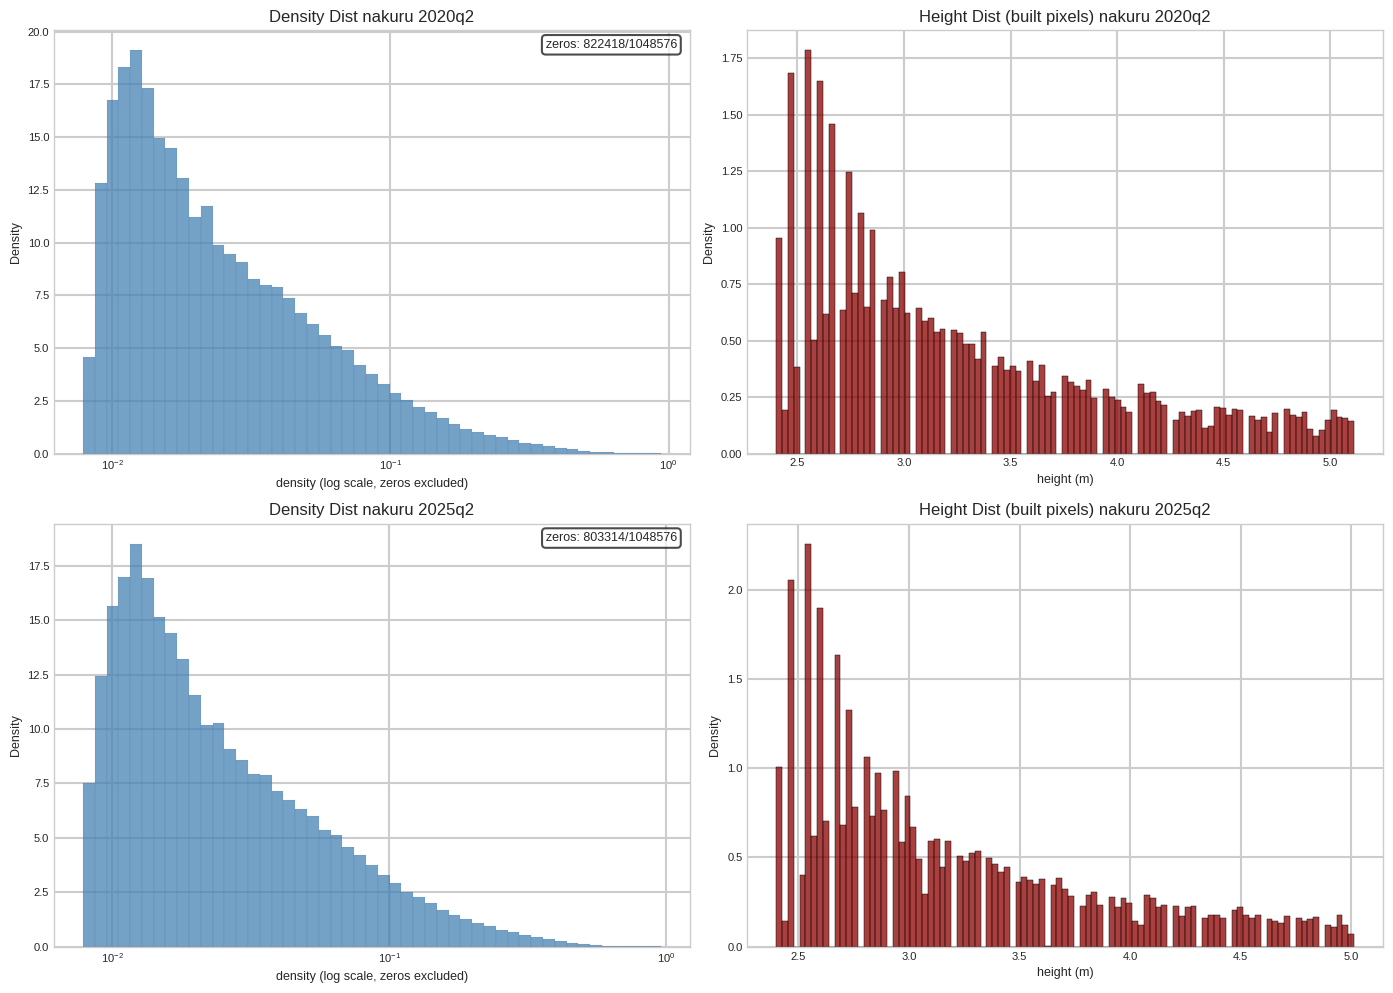

In [19]:
plot_distributions("nakuru", ["2020q2", "2025q2"])

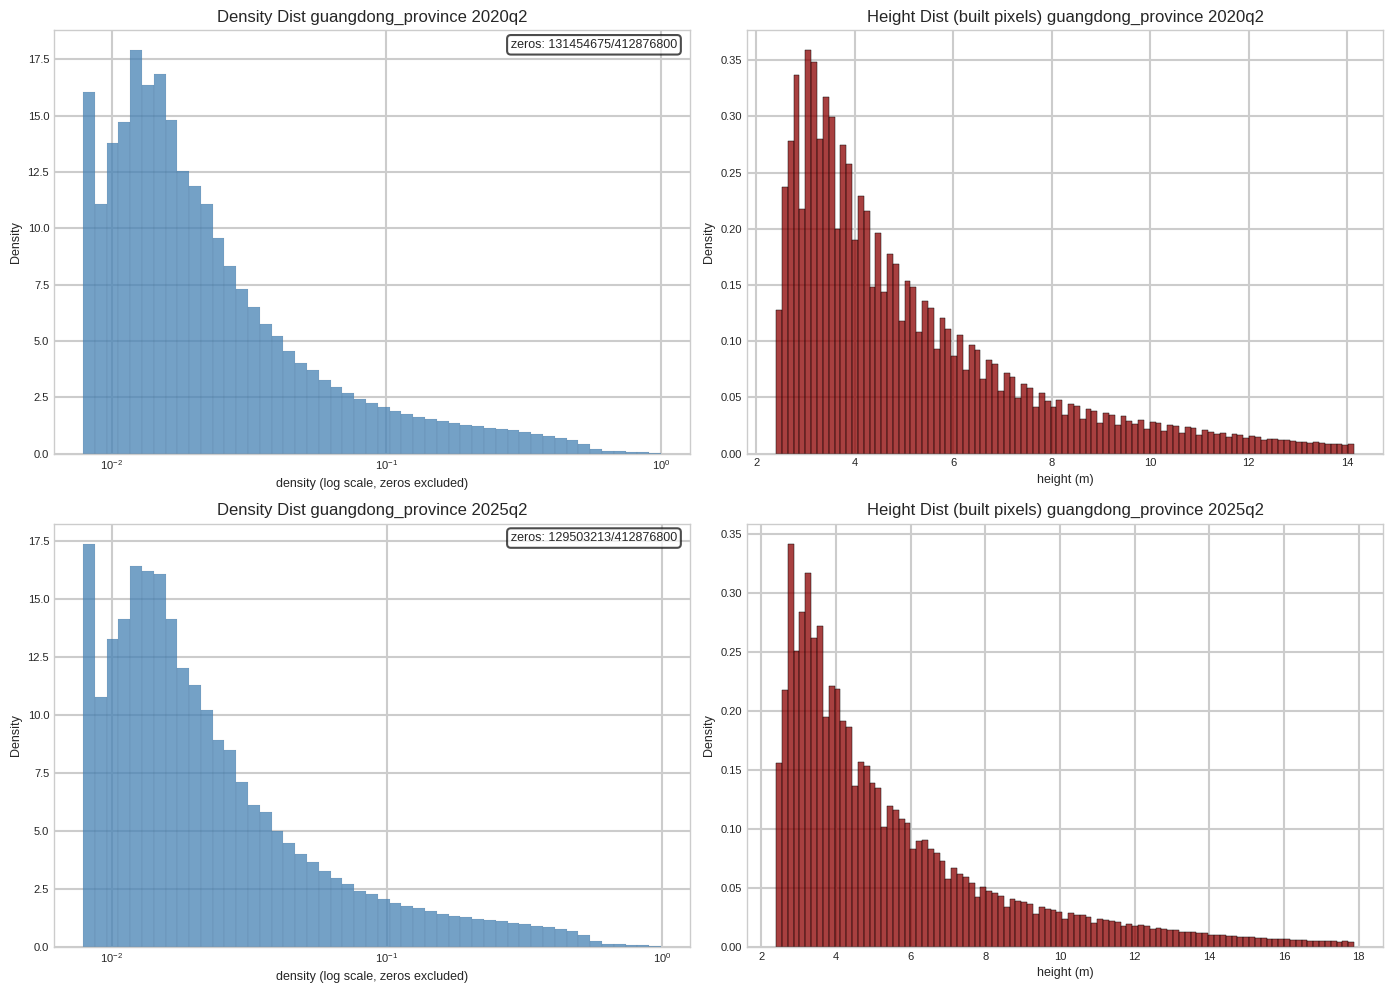

In [20]:
plot_distributions("guangdong_province", ["2020q2", "2025q2"])

### Interpreting Distributional Changes

The distribution plots reveal important contrasts in how urban development is occurring in these two locations:

**Nakuru:**
- **Density distributions** show a relatively stable pattern between 2020q2 and 2025q2, with most built areas remaining at low to moderate density levels. The number of zero-density pixels has decreased slightly (from 822,418 to 803,314 out of ~1.05M total), indicating modest horizontal expansion into previously undeveloped areas.
- **Height distributions** remain tightly concentrated around 2.5-3 meters across both time periods, with minimal change in the distribution shape. This confirms that Nakuru's growth is characterized by infill and horizontal expansion of predominantly single-story or low-rise structures, rather than the introduction of taller buildings.

**Guangdong Province:**
- **Density distributions** also show relative stability but at higher overall density levels than Nakuru, reflecting a more mature urban environment. The slight decrease in zeros (from 131,454,675 to 129,503,213 out of ~412M pixels) indicates continued but modest spatial expansion given the province's already extensive built-up area.
- **Height distributions** reveal a notably broader range (2-14+ meters vs. Nakuru's 2.5-5 meters in 2020q2) and a rightward shift between 2020q2 and 2025q2. This indicates that Guangdong is experiencing genuine vertical intensification, with new taller structures being added to the building stock—consistent with an urban area pursuing upward growth in addition to horizontal expansion.

These distributional differences directly explain why Guangdong shows rising mean heights over time while Nakuru's mean height remains flat, despite both locations experiencing growth in total volume.

## 7. Spatial Change Highlighting

To pinpoint where urban development is occurring within a location, we'll create spatial difference maps that highlight areas of density and height changes between two time periods. This reveals specific neighborhoods experiencing growth or transformation.
Compute difference maps (later quarter minus earlier) to locate expansion or vertical intensification.

In [21]:
def difference_map(location, yq_early, yq_late, size=None):
    """Create spatial difference maps showing changes in density and height.

    Visualizes where urban development has occurred by computing pixel-wise differences
    between two time periods.

    Args:
        location: Location identifier (e.g., 'nakuru', 'guangdong_province')
        yq_early: Earlier year-quarter string (e.g., '2020q2')
        yq_late: Later year-quarter string (e.g., '2025q2')
        size: Optional size to crop the arrays (for faster rendering)
    """
    d_e, h_e, _ = load_tile(location, yq_early)
    d_l, h_l, _ = load_tile(location, yq_late)
    diff_density = d_l - d_e
    diff_height = h_l - h_e

    if size is not None:
        diff_density = diff_density[:size, :size]
        diff_height = diff_height[:size, :size]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=100)

    im0 = axes[0].imshow(
        diff_density, cmap="bwr", vmin=-0.2, vmax=0.2, interpolation="none"
    )
    axes[0].set_title(f"Density Change {yq_early} → {yq_late}", fontsize=20)
    cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    cbar0.ax.tick_params(labelsize=14)
    cbar0.set_label("Δ density", fontsize=16)

    im1 = axes[1].imshow(diff_height, cmap="bwr", vmin=-5, vmax=5, interpolation="none")
    axes[1].set_title(f"Height Change (m) {yq_early} → {yq_late}", fontsize=20)
    cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    cbar1.ax.tick_params(labelsize=14)
    cbar1.set_label("Δ height (m)", fontsize=16)

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

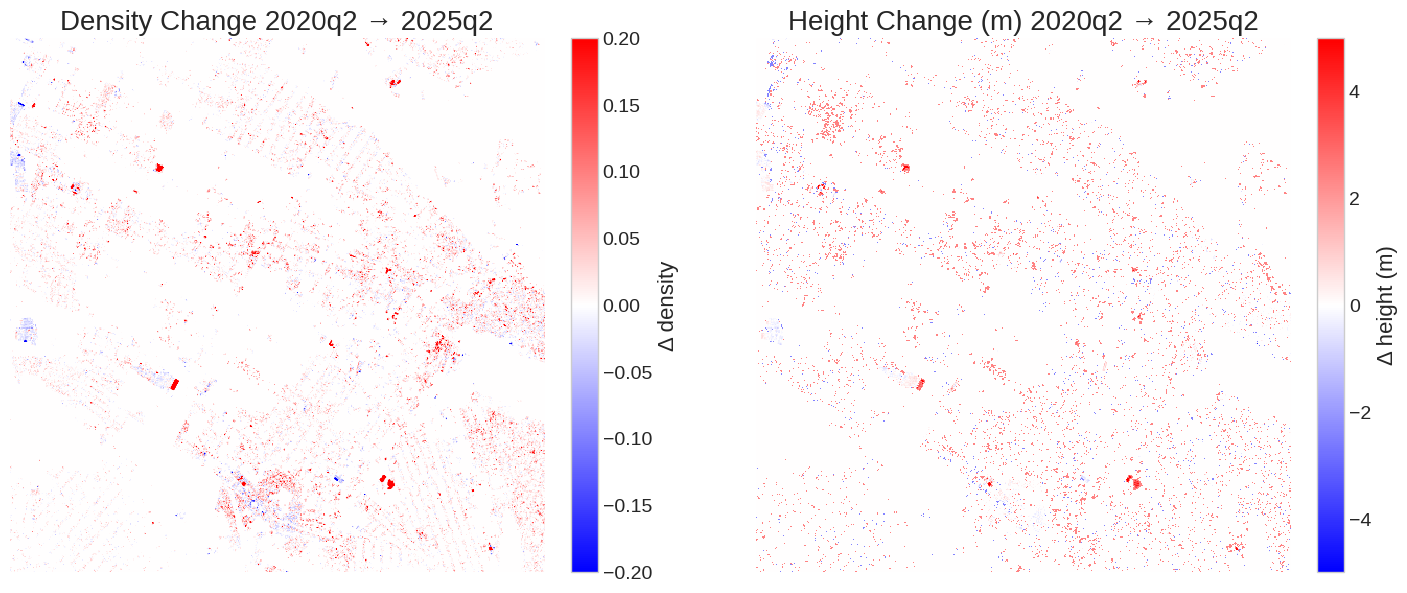

In [22]:
difference_map(
    "nakuru",
    nakuru_df["year_quarter"].iloc[0],
    nakuru_df["year_quarter"].iloc[-1],
    size=512,
)

### Interpretation of Difference Maps
- Red on density panel: new or intensified coverage. Blue: potential reduction (redevelopment).
- Height increases without density change can be explained by vertical redevelopment.
- Joint increases can be explained by new constructions.

## 8. Optional: Simple Animation (Density Evolution)

For a dynamic view of urban development over time, we'll create an animated GIF showing how building density evolves quarter by quarter. This provides an intuitive visualization of growth patterns and helps identify periods of rapid change.

In [ ]:
frames = []

font_size = 28
font = ImageFont.truetype("DejaVuSans.ttf", font_size)

for idx, yq in enumerate(QUARTERS):
    d, h, _ = load_tile("nakuru", yq)
    img = (d * 255).astype(np.uint8)
    pil = Image.fromarray(img, mode="L").convert("RGB")

    draw = ImageDraw.Draw(pil)
    dots = "." * ((idx % 3) + 1)  # animate 1..3 dots
    text = f"{yq} {dots}"

    try:
        bbox = draw.textbbox((0, 0), text, font=font)
        tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except Exception:
        try:
            tw, th = draw.textsize(text, font=font)
        except Exception:
            tw, th = font.getsize(text)

    pad = 6
    rect = (8 - pad // 2, 8 - pad // 2, 8 + tw + pad // 2, 8 + th + pad // 2)
    draw.rectangle(rect, fill=(0, 0, 0))
    draw.text((8, 8), text, fill=(255, 255, 255), font=font)

    frames.append(np.array(pil))

imageio.mimsave("../images/nakuru_density_evolution.gif", frames, fps=5, loop=0)

## 9. Insights & Takeaways

- Both Nakuru and Guangdong show rising mean density, signaling infill and expansion of built coverage.
- However, Nakuru's mean height remains largely flat, pointing to growth driven by horizontal spread and infill rather than vertical construction. In contrast, Guangdong's mean height is climbing, indicating development that is both outward and upward—new footprints accompanied by taller buildings. 
- These dynamics are visible in the density–height scatterplots: rightward motion (horizontal expansion) dominates in Nakuru, while Guangdong exhibits a diagonal up‑right drift characteristic of simultaneous spatial expansion and vertical intensification.
- The volume proxy (combining height and density) reinforces this reading. Nakuru's volume gains are primarily explained by wider built‑up extent, peaking around 2022, while Guangdong's growth reflects a dual engine of added coverage and increasing height, with a growth peak in 2021. 